Restaurant Rating & Cuisine Analysis Data Scrapping

In [1]:
# import the necessary libraries
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json

In [2]:
pip install beautifulsoup4 requests pandas  

Note: you may need to restart the kernel to use updated packages.


In [3]:
# take the url of the website from which we want to scrape the data
url = "https://www.zomato.com/hyderabad/restaurants"

#https://www.zomato.com/hyderabad/restaurants

In [4]:
# create the request to the website by headers to avoid the 403 error
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36"
}

In [5]:
# send the request to the website and get the response
response = requests.get(url, headers=headers)
# check if the request was successful
response.status_code

200

b'\n    <!DOCTYPE html>\n    <html>\n      <head>\n      <meta name="viewport" content="width=device-width, initial-scale=1">\n      <link rel="preconnect" href="https://googleads.g.doubleclick.net">\n      <link rel="preconnect" href="https://jumbo.zomato.com">\n      <link rel="dns-prefetch" href="https://accounts.google.com">\n      <link rel="dns-prefetch" href="https://securepubads.g.doubleclick.net">\n      <link rel="dns-prefetch" href="https://www.google-analytics.com">\n      <link rel="dns-prefetch" href="https://www.googleadservices.com">\n      <link rel="dns-prefetch" href="https://play.google.com">\n      <link rel="dns-prefetch" href="https://bat.bing.com">\n      <link rel="dns-prefetch" href="https://8391443.fls.doubleclick.net">\n      \n      <link rel="preconnect" href="https://b.zmtcdn.com" crossorigin>\n\n      <link rel="preload" href="https://b.zmtcdn.com/web_assets/b27921d5a95f787012c8e9dfbb86c2751597997132.woff2" as="font" type="font/woff2" crossorigin>\n     
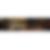
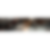
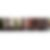
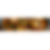
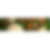
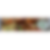
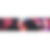
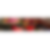
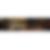
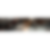
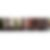
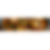
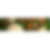
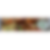
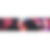
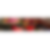

In [6]:
# show the content of the page
response.content


<!DOCTYPE html>

<html>
<head>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<link href="https://googleads.g.doubleclick.net" rel="preconnect"/>
<link href="https://jumbo.zomato.com" rel="preconnect"/>
<link href="https://accounts.google.com" rel="dns-prefetch"/>
<link href="https://securepubads.g.doubleclick.net" rel="dns-prefetch"/>
<link href="https://www.google-analytics.com" rel="dns-prefetch"/>
<link href="https://www.googleadservices.com" rel="dns-prefetch"/>
<link href="https://play.google.com" rel="dns-prefetch"/>
<link href="https://bat.bing.com" rel="dns-prefetch"/>
<link href="https://8391443.fls.doubleclick.net" rel="dns-prefetch"/>
<link crossorigin="" href="https://b.zmtcdn.com" rel="preconnect"/>
<link as="font" crossorigin="" href="https://b.zmtcdn.com/web_assets/b27921d5a95f787012c8e9dfbb86c2751597997132.woff2" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="" href="https://b.zmtcdn.com/web_assets/c750382e5207a1a41cdcb496ef2326d
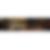
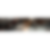
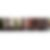
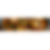
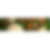
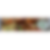
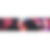
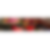
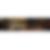
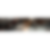
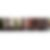
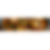
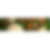
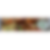
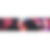
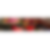

In [7]:
# beautiful sope object to parse the html content of the page
soup = BeautifulSoup(response.content, "html.parser")
print(soup)

In [8]:
# create a empty list to store the data
data = []


In [10]:
"""data = []

for page in range(1, 3):

    page_url = f"{url}?page={page}"

    response = requests.get(
        page_url,
        headers=headers,
        timeout=20
    )

    if response.status_code != 200:
        print(f"Failed to retrieve page {page}. Status code: {response.status_code}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")

    restaurants = soup.find_all(
        "article",
        class_="product_pod"
    )

    print(f"Page {page}: {len(restaurants)} restaurants found")

    for restaurant in restaurants:

        name = restaurant.find("h3").find("a").get("title")

        rating = restaurant.find(
            "p",
            class_="star-rating"
        ).get("class")[1]

        cuisine = restaurant.find(
            "p",
            class_="cuisine"
        ).text.strip()

        location = restaurant.find(
            "p",
            class_="location"
        ).text.strip()

        number_of_reviews = restaurant.find(
            "p",
            class_="reviews"
        ).text.strip()

        average_cost = restaurant.find(
            "p",
            class_="cost"
        ).text.strip()

        delivery_availability = restaurant.find(
            "p",
            class_="availability"
        ).text.strip()

        online_ordering = restaurant.find(
            "p",
            class_="online-ordering"
        ).text.strip()

        restaurant_type = restaurant.find(
            "p",
            class_="restaurant-type"
        ).text.strip()

        data.append({
            "Name": name,
            "Rating": rating,
            "Cuisine": cuisine,
            "Location": location,
            "Number_of_Reviews": number_of_reviews,
            "Average_Cost": average_cost,
            "Delivery_Availability": delivery_availability,
            "Online_Ordering": online_ordering,
            "Restaurant_Type": restaurant_type
        })

print(f"Total restaurants extracted: {len(data)}")
"""

'data = []\n\nfor page in range(1, 3):\n\n    page_url = f"{url}?page={page}"\n\n    response = requests.get(\n        page_url,\n        headers=headers,\n        timeout=20\n    )\n\n    if response.status_code != 200:\n        print(f"Failed to retrieve page {page}. Status code: {response.status_code}")\n        continue\n\n    soup = BeautifulSoup(response.text, "html.parser")\n\n    restaurants = soup.find_all(\n        "article",\n        class_="product_pod"\n    )\n\n    print(f"Page {page}: {len(restaurants)} restaurants found")\n\n    for restaurant in restaurants:\n\n        name = restaurant.find("h3").find("a").get("title")\n\n        rating = restaurant.find(\n            "p",\n            class_="star-rating"\n        ).get("class")[1]\n\n        cuisine = restaurant.find(\n            "p",\n            class_="cuisine"\n        ).text.strip()\n\n        location = restaurant.find(\n            "p",\n            class_="location"\n        ).text.strip()\n\n        number

In [11]:
"""# code to extract the data from the page
for page in range(1,3):
    response = requests.get(url,headers=headers,timeout=20)
    
    if response.status_code != 200:
        print(f"Failed to retrieve page {page}. Status code: {response.status_code}")
        continue


    soup = BeautifulSoup(response.text,"html.parser")
    restaurants = soup.find_all("article",class_="product_pod")


    for restaurant in restaurants:
        name = restaurant.find("h3").find("a").get("title")
        rating = restaurant.find("p",class_="star-rating").get("class")[1]
        cuisine = restaurant.find("p",class_="cuisine").text.strip()
        location = restaurant.find("p",class_="location").text.strip()
        number_of_reviews = restaurant.find("p",class_="reviews").text.strip()
        Average_cost = restaurant.find("p",class_="cost").text.strip()
        Delivery_availability = restaurant.find("p",class_="availability").text.strip()
        Online_ordering = restaurant.find("p",class_="online-ordering").text.strip()
        Restaurant_type = restaurant.find("p",class_="restaurant-type").text.strip()



        data.append({
            "Name": name,
            "Rating": rating,
            "Cuisine": cuisine,
            "Location": location,
            "Number_of_Reviews": number_of_reviews,
            "Average_Cost": Average_cost,
            "Delivery_Availability": Delivery_availability,
            "Online_Ordering": Online_ordering,
            "Restaurant_Type": Restaurant_type
        })
    
"""


'# code to extract the data from the page\nfor page in range(1,3):\n    response = requests.get(url,headers=headers,timeout=20)\n\n    if response.status_code != 200:\n        print(f"Failed to retrieve page {page}. Status code: {response.status_code}")\n        continue\n\n\n    soup = BeautifulSoup(response.text,"html.parser")\n    restaurants = soup.find_all("article",class_="product_pod")\n\n\n    for restaurant in restaurants:\n        name = restaurant.find("h3").find("a").get("title")\n        rating = restaurant.find("p",class_="star-rating").get("class")[1]\n        cuisine = restaurant.find("p",class_="cuisine").text.strip()\n        location = restaurant.find("p",class_="location").text.strip()\n        number_of_reviews = restaurant.find("p",class_="reviews").text.strip()\n        Average_cost = restaurant.find("p",class_="cost").text.strip()\n        Delivery_availability = restaurant.find("p",class_="availability").text.strip()\n        Online_ordering = restaurant.find("

In [13]:
"""
# print the data
for restaurant in data:
    print(f"Name: {restaurant['Name']}")
    print(f"Rating: {restaurant['Rating']}")
    print(f"Price: {restaurant['Price']}")
    print(f"Availability: {restaurant['Availability']}")
    print(f"Cuisine: {restaurant['Cuisine']}")
    print(f"Location: {restaurant['Location']}")
    print(f"Number of Reviews: {restaurant['Number_of_Reviews']}")
    print(f"Average Cost: {restaurant['Average_Cost']}")
    print(f"Delivery Availability: {restaurant['Delivery_Availability']}")
    print(f"Online Ordering: {restaurant['Online_Ordering']}")
    print(f"Restaurant Type: {restaurant['Restaurant_Type']}")

    print("-" * 50)
"""

'\n# print the data\nfor restaurant in data:\n    print(f"Name: {restaurant[\'Name\']}")\n    print(f"Rating: {restaurant[\'Rating\']}")\n    print(f"Price: {restaurant[\'Price\']}")\n    print(f"Availability: {restaurant[\'Availability\']}")\n    print(f"Cuisine: {restaurant[\'Cuisine\']}")\n    print(f"Location: {restaurant[\'Location\']}")\n    print(f"Number of Reviews: {restaurant[\'Number_of_Reviews\']}")\n    print(f"Average Cost: {restaurant[\'Average_Cost\']}")\n    print(f"Delivery Availability: {restaurant[\'Delivery_Availability\']}")\n    print(f"Online Ordering: {restaurant[\'Online_Ordering\']}")\n    print(f"Restaurant Type: {restaurant[\'Restaurant_Type\']}")\n\n    print("-" * 50)\n'

In [14]:
# how many restaurants we have scraped
print(f"Total number of restaurants scraped: {len(data)}")

Total number of restaurants scraped: 0


In [15]:
import requests
from bs4 import BeautifulSoup
import json
import pandas as pd
import time

# --------------------------------------------------
# Headers
# --------------------------------------------------

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/139.0.0.0 Safari/537.36"
}

# --------------------------------------------------
# Indian cities
# --------------------------------------------------

cities = [
    "hyderabad",
    "bangalore",
    "mumbai",
    "delhi",
    "chennai",
    "kolkata",
    "pune",
    "ahmedabad",
    "jaipur",
    "lucknow",
    "surat",
    "indore",
    "bhopal",
    "nagpur",
    "visakhapatnam",
    "patna",
    "vadodara",
    "chandigarh",
    "coimbatore",
    "kochi"
]

# --------------------------------------------------
# Empty list
# --------------------------------------------------

data = []

# --------------------------------------------------
# Scraping
# --------------------------------------------------

for city in cities:

    if len(data) >= 1000:
        break

    url = f"https://www.zomato.com/{city}/restaurants"

    print(f"\nScraping: {city}")

    try:

        response = requests.get(
            url,
            headers=headers,
            timeout=20
        )

        print("Status Code:", response.status_code)

        if response.status_code != 200:
            print(f"Failed to retrieve {city}")
            continue

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        # Find JSON-LD scripts
        scripts = soup.find_all(
            "script",
            type="application/ld+json"
        )

        city_count = 0

        # --------------------------------------------------
        # Extract restaurant data
        # --------------------------------------------------

        for script in scripts:

            try:

                json_data = json.loads(
                    script.string
                )

                # Check ItemList
                if json_data.get("@type") != "ItemList":
                    continue

                restaurants = json_data.get(
                    "itemListElement",
                    []
                )

                for item in restaurants:

                    restaurant = item.get(
                        "item",
                        {}
                    )

                    name = restaurant.get(
                        "name"
                    )

                    rating = restaurant.get(
                        "aggregateRating",
                        {}
                    ).get(
                        "ratingValue"
                    )

                    reviews = restaurant.get(
                        "aggregateRating",
                        {}
                    ).get(
                        "reviewCount"
                    )

                    cuisine = restaurant.get(
                        "servesCuisine"
                    )

                    address = restaurant.get(
                        "address",
                        {}
                    ).get(
                        "streetAddress"
                    )

                    restaurant_url = restaurant.get(
                        "url"
                    )

                    image_url = restaurant.get(
                        "image"
                    )

                    # --------------------------------------------------
                    # Store data
                    # --------------------------------------------------

                    data.append({

                        "Restaurant Name": name,

                        "Rating": rating,

                        "Reviews": reviews,

                        "Cuisine": cuisine,

                        "Address": address,

                        "City": city,

                        "Restaurant URL": restaurant_url,

                        "Image URL": image_url

                    })

                    city_count += 1

                    # Stop at 1000
                    if len(data) >= 1000:
                        break

                if len(data) >= 1000:
                    break

            except Exception as e:

                print(
                    "JSON Error:",
                    e
                )

        print(
            f"{city}: {city_count} records extracted"
        )

        print(
            "Total records:",
            len(data)
        )

        # Small delay
        time.sleep(2)

    except requests.exceptions.RequestException as e:

        print(
            f"Request Error for {city}:",
            e
        )


# --------------------------------------------------
# Convert to DataFrame
# --------------------------------------------------

df = pd.DataFrame(data)

# --------------------------------------------------
# Remove duplicate restaurants
# --------------------------------------------------

df.drop_duplicates(
    subset=["Restaurant Name", "City"],
    inplace=True
)

# --------------------------------------------------
# Keep only first 1000 records
# --------------------------------------------------

df = df.head(1000)

# --------------------------------------------------
# Reset index
# --------------------------------------------------

df.reset_index(
    drop=True,
    inplace=True
)

# --------------------------------------------------
# Display
# --------------------------------------------------

print("\nFinal Dataset")
print("--------------------")

print("Total Records:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
print(df.head())

# --------------------------------------------------
# Save CSV
# --------------------------------------------------

df.to_csv(
    "zomato_india_1000_restaurants.csv",
    index=False
)

print(
    "\nCSV file saved successfully!"
)

print(
    "File: zomato_india_1000_restaurants.csv"
)


Scraping: hyderabad
Status Code: 200
hyderabad: 9 records extracted
Total records: 9

Scraping: bangalore
Status Code: 200
bangalore: 9 records extracted
Total records: 18

Scraping: mumbai
Status Code: 200
mumbai: 9 records extracted
Total records: 27

Scraping: delhi
Status Code: 404
Failed to retrieve delhi

Scraping: chennai
Status Code: 200
chennai: 9 records extracted
Total records: 36

Scraping: kolkata
Status Code: 200
kolkata: 9 records extracted
Total records: 45

Scraping: pune
Status Code: 200
pune: 9 records extracted
Total records: 54

Scraping: ahmedabad
Status Code: 200
ahmedabad: 9 records extracted
Total records: 63

Scraping: jaipur
Status Code: 200
jaipur: 9 records extracted
Total records: 72

Scraping: lucknow
Status Code: 200
lucknow: 9 records extracted
Total records: 81

Scraping: surat
Status Code: 200
surat: 9 records extracted
Total records: 90

Scraping: indore
Status Code: 200
indore: 9 records extracted
Total records: 99

Scraping: bhopal
Status Code: 20

In [ ]:
import time
import json
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup


# ============================================================
# CHROME SETUP
# ============================================================

options = Options()

options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")

# If you don't want Chrome window to open, uncomment:
# options.add_argument("--headless=new")

driver = webdriver.Chrome(options=options)


# ============================================================
# INDIAN CITIES
# ============================================================

cities = [
    "hyderabad",
    "bangalore",
    "mumbai",
    "chennai",
    "kolkata",
    "pune",
    "ahmedabad",
    "jaipur",
    "lucknow",
    "surat",
    "indore",
    "bhopal",
    "nagpur",
    "visakhapatnam",
    "patna",
    "vadodara",
    "chandigarh",
    "coimbatore",
    "kochi",
    "mysore",
    "goa",
    "agra",
    "kanpur",
    "nashik",
    "rajkot"
]


# ============================================================
# EMPTY LIST
# ============================================================

data = []

seen = set()

TARGET_RECORDS = 1000


# ============================================================
# SCRAPE CITY
# ============================================================

for city in cities:

    if len(data) >= TARGET_RECORDS:
        break

    url = f"https://www.zomato.com/{city}/restaurants"

    print("\n" + "=" * 60)
    print("Scraping:", city)
    print("=" * 60)

    try:

        driver.get(url)

        time.sleep(5)

        # ----------------------------------------------------
        # SCROLL PAGE
        # ----------------------------------------------------

        last_height = driver.execute_script(
            "return document.body.scrollHeight"
        )

        scroll_count = 0

        while len(data) < TARGET_RECORDS and scroll_count < 30:

            driver.execute_script(
                "window.scrollTo(0, document.body.scrollHeight);"
            )

            time.sleep(3)

            new_height = driver.execute_script(
                "return document.body.scrollHeight"
            )

            scroll_count += 1

            print(
                f"Scroll {scroll_count} | "
                f"Records collected: {len(data)}"
            )

            if new_height == last_height:

                # Try one more wait
                time.sleep(3)

                new_height = driver.execute_script(
                    "return document.body.scrollHeight"
                )

                if new_height == last_height:
                    break

            last_height = new_height


        # ----------------------------------------------------
        # GET PAGE SOURCE
        # ----------------------------------------------------

        html = driver.page_source

        soup = BeautifulSoup(
            html,
            "html.parser"
        )


        city_count = 0


        # ====================================================
        # METHOD 1: JSON-LD
        # ====================================================

        scripts = soup.find_all(
            "script",
            type="application/ld+json"
        )


        for script in scripts:

            if not script.string:
                continue

            try:

                json_data = json.loads(
                    script.string
                )

            except Exception:

                continue


            # ------------------------------------------------
            # ITEM LIST
            # ------------------------------------------------

            if json_data.get("@type") != "ItemList":
                continue


            restaurants = json_data.get(
                "itemListElement",
                []
            )


            for item in restaurants:

                restaurant = item.get(
                    "item",
                    {}
                )


                name = restaurant.get(
                    "name"
                )


                if not name:
                    continue


                # --------------------------------------------
                # UNIQUE KEY
                # --------------------------------------------

                restaurant_url = restaurant.get(
                    "url"
                )

                key = (
                    name.strip().lower(),
                    city
                )


                if key in seen:
                    continue


                seen.add(key)


                # --------------------------------------------
                # RATING
                # --------------------------------------------

                rating_data = restaurant.get(
                    "aggregateRating",
                    {}
                )


                rating = rating_data.get(
                    "ratingValue"
                )


                reviews = rating_data.get(
                    "reviewCount"
                )


                # --------------------------------------------
                # ADDRESS
                # --------------------------------------------

                address_data = restaurant.get(
                    "address",
                    {}
                )


                address = address_data.get(
                    "streetAddress"
                )


                # --------------------------------------------
                # CUISINE
                # --------------------------------------------

                cuisine = restaurant.get(
                    "servesCuisine"
                )


                # --------------------------------------------
                # IMAGE
                # --------------------------------------------

                image = restaurant.get(
                    "image"
                )


                # --------------------------------------------
                # SAVE
                # --------------------------------------------

                data.append({

                    "Restaurant Name": name,

                    "Rating": rating,

                    "Reviews": reviews,

                    "Cuisine": cuisine,

                    "Address": address,

                    "City": city,

                    "Restaurant URL": restaurant_url,

                    "Image URL": image

                })


                city_count += 1


                if len(data) >= TARGET_RECORDS:
                    break


            if len(data) >= TARGET_RECORDS:
                break


        print(
            f"{city}: {city_count} new records"
        )

        print(
            "Total records:",
            len(data)
        )


        time.sleep(2)


    except Exception as e:

        print(
            f"Error while scraping {city}:",
            e
        )

        continue


# ============================================================
# CLOSE BROWSER
# ============================================================

driver.quit()


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(data)


# ============================================================
# REMOVE DUPLICATES
# ============================================================

df.drop_duplicates(
    subset=[
        "Restaurant Name",
        "City"
    ],
    inplace=True
)


# ============================================================
# LIMIT TO 1000
# ============================================================

df = df.head(
    TARGET_RECORDS
)


# ============================================================
# RESET INDEX
# ============================================================

df.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# SAVE CSV
# ============================================================

df.to_csv(
    "zomato_india_1000_restaurants.csv",
    index=False
)


# ============================================================
# FINAL RESULT
# ============================================================

print("\n")
print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print(
    "Total Records:",
    len(df)
)

print(
    "Total Cities:",
    df["City"].nunique()
)

print(
    "Duplicate Records:",
    df.duplicated(
        subset=[
            "Restaurant Name",
            "City"
        ]
    ).sum()
)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 records:")
print(df.head(10))

print("\nCSV saved as:")
print("zomato_india_1000_restaurants.csv")


Scraping: hyderabad
Scroll 1 | Records collected: 0
Scroll 2 | Records collected: 0
Scroll 3 | Records collected: 0
Scroll 4 | Records collected: 0
Scroll 5 | Records collected: 0
Scroll 6 | Records collected: 0
Scroll 7 | Records collected: 0
Scroll 8 | Records collected: 0
Scroll 9 | Records collected: 0
Scroll 10 | Records collected: 0
Scroll 11 | Records collected: 0
Scroll 12 | Records collected: 0
Scroll 13 | Records collected: 0
Scroll 14 | Records collected: 0
hyderabad: 494 new records
Total records: 494

Scraping: bangalore
Scroll 1 | Records collected: 494
Scroll 2 | Records collected: 494
Scroll 3 | Records collected: 494
Scroll 4 | Records collected: 494
Scroll 5 | Records collected: 494
Scroll 6 | Records collected: 494
Scroll 7 | Records collected: 494
Scroll 8 | Records collected: 494
Scroll 9 | Records collected: 494
Scroll 10 | Records collected: 494
Scroll 11 | Records collected: 494
Scroll 12 | Records collected: 494
Scroll 13 | Records collected: 494
Scroll 14 | R

In [19]:
!pip install selenium pandas beautifulsoup4

  Using cached selenium-4.48.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached trio-0.34.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached trio_websocket-0.12.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached websocket_client-1.9.2-py3-none-any.whl.metadata (8.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached outcome-1.3.0.post0-py2.py3-none-any.whl.metadata (2.6 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached cffi-2.1.1-cp314-cp314-win_amd64.whl.metadata (2.6 kB)
  Using cached wsproto-1.3.2-py3-none-any.whl.metadata (5.2 kB)
  Using cached PySocks-1.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached selenium-4.48.0-py3-none-any.whl (9.6 MB)
Using cached trio-0.34.0-py3-none-any.whl (511 kB)
Using cached trio_webs